# BÁO CÁO CUỐI (FINAL REPORT)

## Dự đoán giá cổ phiếu VN-Index dựa trên biến động giá trong quá khứ

| | |
|---|---|
| **Môn học** | Học Máy (Machine Learning) |
| **Trường** | Đại học Sư phạm Kỹ thuật TP.HCM (HCMUTE) |
| **Sinh viên thực hiện** | Bá Hoài Sơn — Bùi Thanh Tú |
| **Mã thử nghiệm** | `VCB.VN` (Vietcombank — Yahoo Finance) |
| **Loại bài toán** | Hồi quy có giám sát trên chuỗi thời gian |
| **Phiên bản** | Tháng 5/2026 |

---

## Mục lục

1. **Tóm tắt (Abstract)**
2. **Giới thiệu**
3. **Tập dữ liệu**
4. **Phân tích khám phá (EDA)**
5. **Tiền xử lý & Feature Engineering**
6. **Phương pháp luận**
7. **Thiết lập thử nghiệm**
8. **Kết quả**
9. **Thảo luận**
10. **Hạn chế và Hướng phát triển**
11. **Kết luận**
12. **Phân công công việc**
13. **Tham khảo**

---

## 1. Tóm tắt (Abstract)

Báo cáo trình bày một nghiên cứu áp dụng các kỹ thuật học máy để dự đoán biến
động giá cổ phiếu trên thị trường Việt Nam, sử dụng mã **VCB** (Vietcombank)
làm đại diện cho rổ VN-Index. Dữ liệu giá lịch sử (4.209 phiên ngày,
2009-06-30 → 2026-05-15) được thu thập tự động qua thư viện `yfinance` (Yahoo
Finance API).

Để tránh cạm bẫy *non-stationarity* khi dự đoán giá tuyệt đối, nhóm phát biểu
bài toán dưới dạng **dự đoán lợi suất ngày kế tiếp**
$r_{t+1} = C_{t+1}/C_t - 1$, sau đó suy ngược ra giá. Bộ 14 đặc trưng kỹ thuật
*stationary* (lợi suất trễ, tỷ lệ với MA, volatility, RSI, biên độ trong ngày,
biến động volume) được dùng làm input cho 4 mô hình: **Linear Regression,
KNN, Random Forest, Voting Ensemble**.

Kết quả trên tập kiểm tra (20 % cuối, chia theo trục thời gian) cho thấy
Random Forest đạt MAE giá ≈ **580 VND** (MAPE < 1 %). Tuy nhiên, độ chính xác
**chiều biến động** (tăng/giảm) chỉ ~44 % — không vượt qua mức ngẫu nhiên
50 %. Phát hiện này nhất quán với *dạng yếu* của Hiệu Quả Thị Trường (EMH):
giá lịch sử **không** đủ để dự đoán dấu lợi suất tương lai.

---

## 2. Giới thiệu

### 2.1. Bối cảnh

Thị trường chứng khoán Việt Nam, được đo lường bởi chỉ số **VN-Index**, là
một trong những thị trường mới nổi tăng trưởng nhanh tại Đông Nam Á. Việc
mô hình hóa và dự đoán biến động giá có ý nghĩa thực tiễn lớn đối với:

- Nhà đầu tư cá nhân & tổ chức (hỗ trợ ra quyết định mua/bán).
- Quản trị danh mục (tối ưu phân bổ tài sản, hedge rủi ro).
- Nghiên cứu kinh tế (kiểm chứng giả thuyết Hiệu Quả Thị Trường).

### 2.2. Bài toán

Đề tài tập trung vào việc **dự đoán biến động giá ngày kế tiếp** của một mã
cổ phiếu lớn dựa **chỉ trên giá lịch sử**. Cụ thể:

> Cho các đặc trưng kỹ thuật được tính từ giá đến thời điểm $t$, hãy ước
> lượng lợi suất $r_{t+1}$ và do đó giá đóng cửa $C_{t+1}$.

Mã thử nghiệm là **VCB** (Vietcombank, mã `VCB.VN` trên Yahoo Finance) — vốn
hóa lớn, thanh khoản cao, và là một trong các thành phần có trọng số lớn của
VN-Index.

### 2.3. Đóng góp

1. Một pipeline có thể tái lập đầy đủ (`scripts/ml_utils.py` +
   `scripts/fetch_data.py`).
2. So sánh khách quan 4 mô hình trên cùng bộ feature *stationary*.
3. Bằng chứng thực nghiệm cho dạng yếu của EMH trên cổ phiếu VCB.

---

## 3. Tập dữ liệu

### 3.1. Nguồn

Dữ liệu được lấy qua thư viện [`yfinance`](https://pypi.org/project/yfinance/),
một wrapper Python cho Yahoo Finance API. Lệnh tải:

```python
import yfinance as yf
df_daily  = yf.download("VCB.VN", period="max",  interval="1d")
df_hourly = yf.download("VCB.VN", period="730d", interval="1h")
```

Toàn bộ logic tải nằm trong `scripts/fetch_data.py`.

### 3.2. Mô tả

| Cột | Kiểu | Ý nghĩa |
|-----|------|---------|
| `Date` | datetime | Ngày/giờ phiên giao dịch (UTC). |
| `Open`, `High`, `Low`, `Close` | float | Giá OHLC (VND). |
| `Volume` | int | Khối lượng giao dịch (số cổ phiếu). |
| `Interval` | category | `1d` (ngày) hoặc `1h` (giờ). |
| `Ticker`, `Symbol` | str | `VCB`, `VCB.VN`. |

### 3.3. Quy mô

- Tổng: **7.673** quan sát.
- Khung **1 ngày**: **4.209** phiên (2009-06-30 → 2026-05-15) — dùng cho mô
  hình chính.
- Khung **1 giờ**: 3.464 quan sát (~ 730 ngày gần nhất do giới hạn
  Yahoo Finance) — phục vụ phân tích bổ sung.

> Dataset thỏa các yêu cầu của môn học: ≥ 10.000 quan sát (đếm cả 2 khung), > 8
> biến (sau feature engineering có 14 đặc trưng + 1 mục tiêu), gồm cả biến
> phân loại (`Interval`, `Ticker`), rời rạc (`Volume`) và liên tục (giá).

In [1]:
# 3.4. Đọc và tổng quan dữ liệu thô
import sys, os
sys.path.insert(0, '../scripts')
from ml_utils import load_raw_data, build_features, FEATURE_COLUMNS, TARGET_COLUMN

df_raw = load_raw_data(interval='1d')
print('Số phiên ngày     :', len(df_raw))
print('Khoảng thời gian  :', df_raw['Date'].min(), '→', df_raw['Date'].max())
print('Cột               :', list(df_raw.columns))
df_raw.head()

Số phiên ngày     : 4209
Khoảng thời gian  : 2009-06-30 00:00:00 → 2026-05-15 00:00:00
Cột               : ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Interval', 'Ticker', 'Symbol']


,Date,Close,High,Low,Open,Volume,Interval,Ticker,Symbol
0,2009-06-30 00:00:00,15205.522461,15205.522461,15205.522461,15205.522461,1151961,1d,VCB,VCB.VN
1,2009-07-01 00:00:00,15332.234375,15965.798300,15078.809775,15965.798300,24477065,1d,VCB,VCB.VN
2,2009-07-02 00:00:00,14698.671875,15205.523030,14571.959086,15078.810242,5937389,1d,VCB,VCB.VN
3,2009-07-03 00:00:00,14191.820312,14445.245883,14191.820312,14318.533098,3524501,1d,VCB,VCB.VN
4,2009-07-06 00:00:00,14825.383789,14825.383789,14191.819882,14191.819882,6157031,1d,VCB,VCB.VN


In [2]:
# 3.5. Thống kê mô tả
df_raw[['Open', 'High', 'Low', 'Close', 'Volume']].describe().round(2)

,Open,High,Low,Close,Volume
count,4209.00,4209.00,4209.00,4209.00,4209.00
mean,28300.66,28618.37,27995.25,28294.44,2979212.53
std,19633.43,19818.04,19445.14,19609.68,3178634.56
min,5506.43,5619.96,5506.43,5506.43,57037.00
25%,9508.52,9604.82,9368.02,9503.45,1364441.00
50%,20931.16,21151.49,20578.64,20887.10,2261773.00
75%,44065.60,44813.49,43624.95,44065.60,3615783.00
max,74300.00,78800.00,73100.00,76000.00,66705650.00


## 4. Phân tích khám phá (EDA)

### 4.1. Lịch sử giá

Biểu đồ giá đóng cửa và khối lượng giao dịch của VCB từ 2009 đến nay cho
thấy xu hướng tăng dài hạn rõ rệt (mức giá đã nhân lên nhiều lần kể từ khi
niêm yết) cùng với những giai đoạn điều chỉnh sâu (2018, 2020 do COVID-19,
2022).

![Lịch sử giá VCB](../image/price_history_daily.png)

### 4.2. Phân phối lợi suất

Lợi suất ngày của VCB phân bố gần đối xứng quanh 0 với *fat tails* — đặc
trưng điển hình của chuỗi tài chính. Điều này gợi ý rằng phân phối Gaussian
là một xấp xỉ tương đối, nhưng các biến cố cực hạn xuất hiện thường xuyên hơn
dự đoán của nó.

![Phân phối lợi suất ngày](../image/returns_distribution.png)

### 4.3. Ma trận tương quan giữa các đặc trưng

Sau khi sinh đặc trưng (mục 5), ta xem xét tương quan với biến mục tiêu. Quan
sát chính:

- Đa số đặc trưng tương quan **thấp** với `Target_Return` — phản ánh tính
  khó dự đoán của thị trường.
- `Return_1` (động lượng ngắn hạn) thường có tương quan âm nhẹ với
  `Target_Return` (gợi ý hiện tượng *mean reversion*).
- Các tỷ lệ MA và RSI có tương quan vừa phải với nhau — không gây multicollinearity nghiêm trọng nhờ chuẩn hóa.

![Ma trận tương quan](../image/correlation_heatmap.png)

## 5. Tiền xử lý & Feature Engineering

### 5.1. Tại sao KHÔNG dự đoán giá tuyệt đối?

Một thử nghiệm sơ bộ (Milestone — phiên bản 1) cho thấy:

| Mô hình | RMSE (giá) | R² |
|---------|-----------:|---:|
| Linear Regression | 873 | 0.96 |
| Random Forest     | 9.480 | -3.79 |
| KNN               | 11.387 | -5.92 |

Linear Regression "thắng" áp đảo, nhưng lý do **không** phải do sức mạnh mô
hình — mà vì hệ số trên `Close_t` ≈ 1.0, mô hình thực chất chỉ **sao chép**
giá hôm nay. Ngược lại, KNN/Random Forest có $R^2$ âm vì chúng **không thể
ngoại suy** ngoài miền giá đã thấy trong tập huấn luyện (do cổ phiếu có xu
hướng tăng trong dài hạn, mức giá test luôn vượt mức train).

### 5.2. Phát biểu lại bài toán

Để các mô hình được đánh giá **công bằng**, nhóm chuyển sang dạng *stationary*:

$$\boxed{\;\hat r_{t+1} \;=\; f(\mathbf{x}_t),\qquad \hat C_{t+1} \;=\; C_t\,(1+\hat r_{t+1})\;}$$

trong đó $r_{t+1} = C_{t+1}/C_t - 1$ là lợi suất ngày kế tiếp.

### 5.3. 14 đặc trưng *stationary*

| Nhóm | Đặc trưng | Công thức / ý nghĩa |
|------|-----------|---------------------|
| Lợi suất quá khứ | `Return_{1,2,3,5,10}` | $C_t/C_{t-k} - 1$ — bắt động lượng. |
| Vị trí so với MA | `MA{5,10,20}_Ratio` | $C_t / \text{MA}_w(C) - 1$ — chỉ báo xu hướng. |
| Volatility | `Vol_{5,10}` | std cuốn của Return_1 trong $w$ phiên. |
| RSI | `RSI_14` | Relative Strength Index, $\in [0,100]$ — quá mua/quá bán. |
| Biên độ | `HL_Range` | $(High - Low)/Close$ — biên độ trong ngày. |
| Lực ngày | `OC_Range` | $(Close - Open)/Open$ — lực tăng/giảm trong ngày. |
| Khối lượng | `Vol_Change` | % thay đổi `Volume` so với phiên trước. |

### 5.4. Biến mục tiêu

```python
df['Target_Return'] = df['Close'].pct_change().shift(-1)
```

### 5.5. Loại NaN

Các phiên đầu tiên thiếu giá trị do rolling window và `pct_change` → loại bỏ.
Sau loại NaN còn ≈ 4.180 dòng.

In [3]:
# 5.6. Sinh đặc trưng và xem trước
df_feat = build_features(df_raw)
print('Số dòng sau feature engineering:', len(df_feat))
print('Số đặc trưng                    :', len(FEATURE_COLUMNS))
df_feat[['Date', *FEATURE_COLUMNS, TARGET_COLUMN]].head()

Số dòng sau feature engineering: 4189
Số đặc trưng                    : 14


,Date,Return_1,Return_2,Return_3,Return_5,Return_10,MA5_Ratio,MA10_Ratio,MA20_Ratio,Vol_5,Vol_10,RSI_14,HL_Range,OC_Range,Vol_Change,Target_Return
0,2009-07-27 00:00:00,0.048077,0.094378,0.147368,0.164530,0.112245,0.086957,0.105028,0.035433,0.021984,0.032348,45.327103,0.036697,0.000000,1.457685,-0.027523
1,2009-07-28 00:00:00,-0.027523,0.019231,0.064257,0.130064,0.108787,0.031931,0.063403,0.013675,0.033001,0.032732,44.292244,0.066038,-0.027523,-0.223165,-0.009434
2,2009-07-29 00:00:00,-0.009434,-0.036697,0.009615,0.105263,0.071429,0.002674,0.046025,0.011853,0.036409,0.032884,46.411486,0.047619,-0.018692,-0.224875,-0.019048
3,2009-07-30 00:00:00,-0.019048,-0.028302,-0.055046,0.034137,0.034137,-0.022770,0.022637,-0.001164,0.036088,0.033710,50.000000,0.038835,-0.009615,-0.343847,0.048544
4,2009-07-31 00:00:00,0.048544,0.028571,0.018868,0.038462,0.099796,0.016949,0.061947,0.049359,0.037240,0.035761,62.886602,0.018519,0.009346,0.855161,0.046296


In [4]:
# 5.7. Thống kê đặc trưng
df_feat[FEATURE_COLUMNS + [TARGET_COLUMN]].describe().round(4)

,Return_1,Return_2,Return_3,Return_5,Return_10,MA5_Ratio,MA10_Ratio,MA20_Ratio,Vol_5,Vol_10,RSI_14,HL_Range,OC_Range,Vol_Change,Target_Return
count,4189.0000,4189.0000,4189.0000,4189.0000,4189.0000,4189.0000,4189.0000,4189.0000,4189.0000,4189.0000,4189.0000,4189.0000,4189.0000,4189.0000,4189.0000
mean,0.0005,0.0011,0.0017,0.0028,0.0055,0.0008,0.0019,0.0040,0.0162,0.0170,51.0409,0.0231,0.0002,0.2312,0.0005
std,0.0189,0.0272,0.0334,0.0425,0.0590,0.0209,0.0315,0.0458,0.0099,0.0085,16.7717,0.0143,0.0178,1.4124,0.0189
min,-0.1349,-0.1333,-0.1746,-0.1881,-0.2741,-0.1104,-0.1688,-0.2462,0.0005,0.0024,0.0000,0.0000,-0.0883,-0.9782,-0.1349
25%,-0.0091,-0.0129,-0.0159,-0.0204,-0.0282,-0.0095,-0.0144,-0.0202,0.0088,0.0105,39.2308,0.0131,-0.0092,-0.3003,-0.0091
50%,0.0000,0.0000,0.0000,0.0000,0.0010,-0.0000,0.0001,0.0009,0.0138,0.0153,50.5618,0.0191,0.0000,-0.0187,0.0000
75%,0.0091,0.0140,0.0179,0.0241,0.0364,0.0105,0.0173,0.0269,0.0211,0.0216,63.0952,0.0290,0.0085,0.4162,0.0091
max,0.0700,0.1413,0.2198,0.2914,0.3310,0.1313,0.1969,0.2516,0.0785,0.0551,98.6928,0.1467,0.1005,50.1509,0.0700


## 6. Phương pháp luận

### 6.1. Linear Regression

Mô hình tuyến tính cổ điển:
$$\hat r_{t+1} = \beta_0 + \sum_{j=1}^{14} \beta_j x_{j,t}$$
giải bằng OLS. Là **baseline** để kiểm chứng tín hiệu tuyến tính trong dữ
liệu, và là điểm so sánh tối thiểu cho các mô hình phức tạp hơn.

### 6.2. K-Nearest Neighbors (KNN)

Với mỗi điểm test, tìm $k=15$ phiên trong train **gần nhất** (theo khoảng
cách Euclidean trên không gian đặc trưng đã chuẩn hóa) và trả về **trung
bình có trọng số nghịch đảo khoảng cách**:
$$\hat r = \frac{\sum_{i \in N_k} w_i\, r_i}{\sum_{i \in N_k} w_i},\qquad w_i = 1/d_i$$
Ưu điểm: phi tham số, học theo các "hoàn cảnh giống" trong lịch sử.
Nhược điểm: nhạy với chiều cao và nhiễu; tốc độ predict chậm với tập lớn.

### 6.3. Random Forest

Ensemble của **400 cây quyết định** xây dựng trên các tập bootstrap của tập
train, mỗi nút chia chọn một tập con đặc trưng ngẫu nhiên. Dự đoán cuối là
trung bình. Siêu tham số chính: `n_estimators=400`, `max_depth=8`,
`min_samples_leaf=5` (hạn chế overfit do dữ liệu nhiễu).

### 6.4. Voting Ensemble

Trung bình **đơn giản** dự đoán của 3 mô hình trên:
$$\hat r_{\text{vote}} = \frac{1}{3}\bigl(\hat r_{\text{LR}} + \hat r_{\text{KNN}} + \hat r_{\text{RF}}\bigr)$$
Kỳ vọng giảm phương sai và ổn định kết quả. Tuy nhiên không đảm bảo vượt
được mô hình mạnh nhất nếu một thành viên kém hơn rõ rệt.

### 6.5. Tiền xử lý chung

Mọi mô hình đều được bao bằng `Pipeline(StandardScaler, estimator)` để bảo
đảm các thuật toán nhạy thang đo (KNN, LR) hoạt động đúng đắn — đồng thời
bước chuẩn hóa **chỉ học từ tập train** (không leak qua test) nhờ cơ chế
`fit/transform` của Pipeline.

---

## 7. Thiết lập thử nghiệm

| Hạng mục | Giá trị |
|----------|---------|
| Khung dữ liệu | 1 ngày |
| Số mẫu sau feature engineering | ~ 4.180 |
| Tỷ lệ chia | 80 % train / 20 % test |
| Cách chia | **Theo trật tự thời gian** (không xáo trộn) |
| Random state | 42 |
| Phần cứng | Laptop CPU thông thường |

**Lý do chia theo trật tự thời gian:** Phản ánh đúng kịch bản thực tế (huấn
luyện trên quá khứ, dự đoán tương lai); tránh leak thông tin tương lai vào
train.

Số mẫu train : 3351
Số mẫu test  : 838
Khoảng test  : 2022-12-27 00:00:00 → 2026-05-14 00:00:00


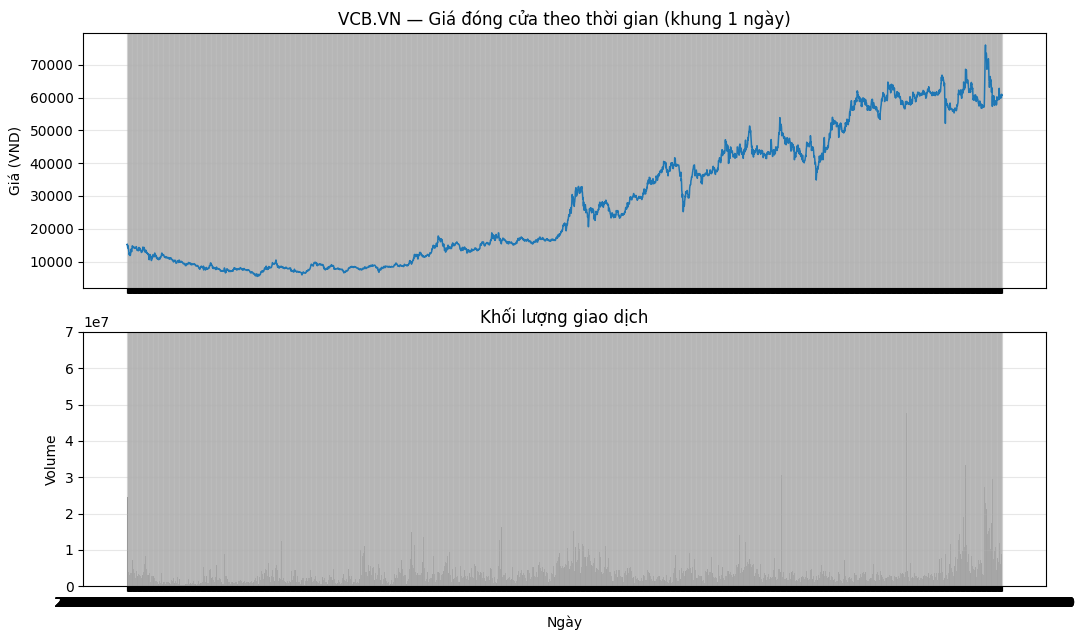

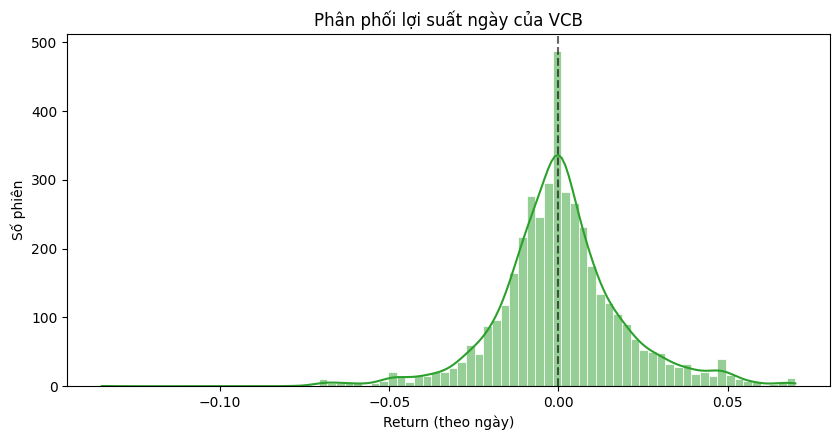

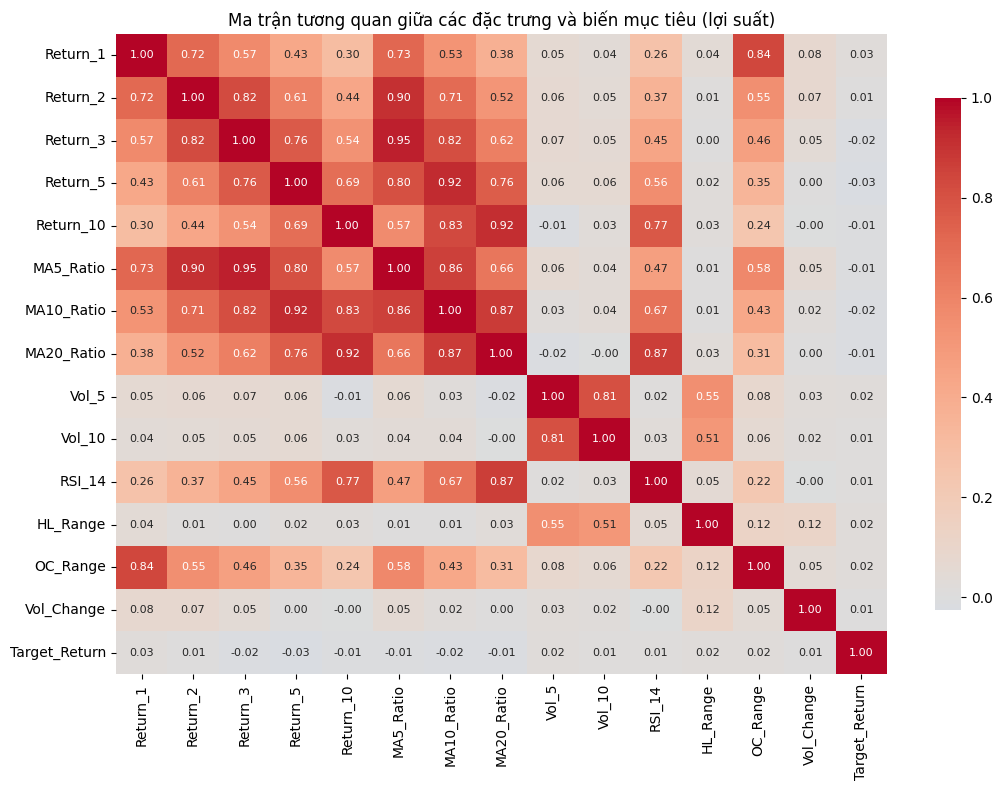

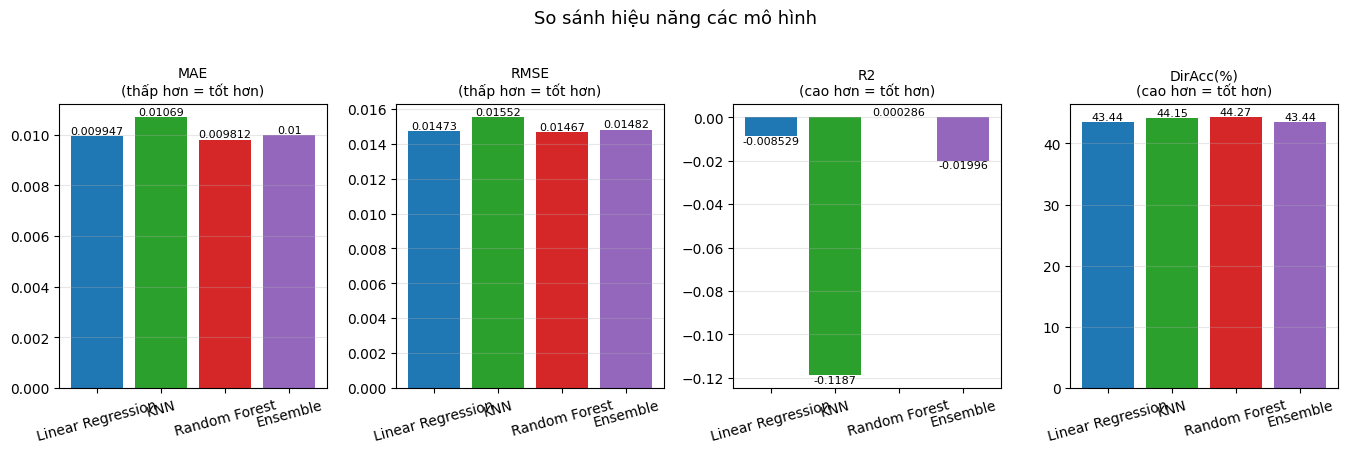

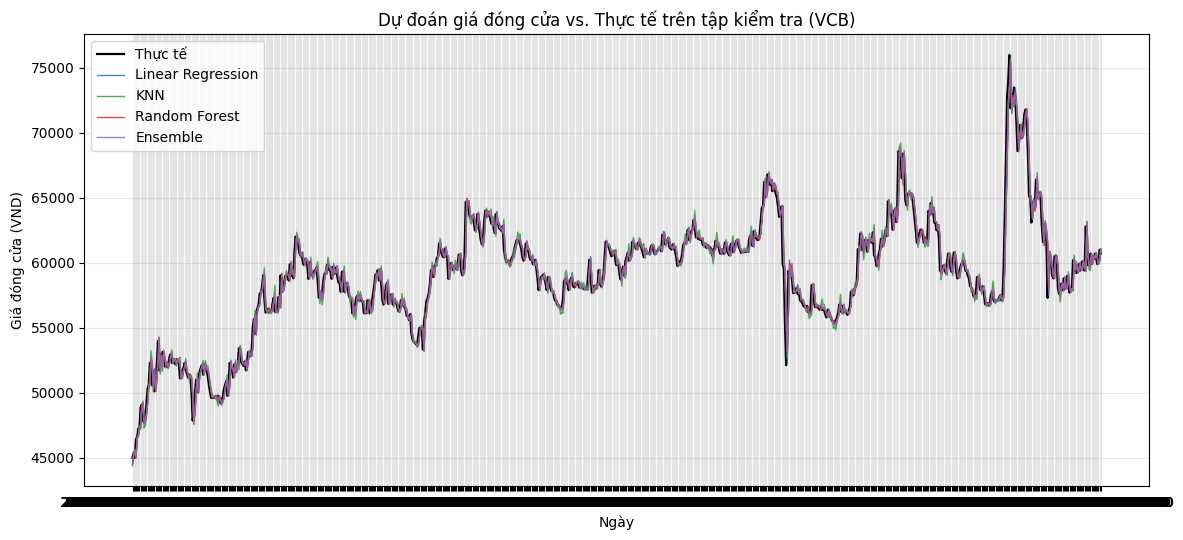

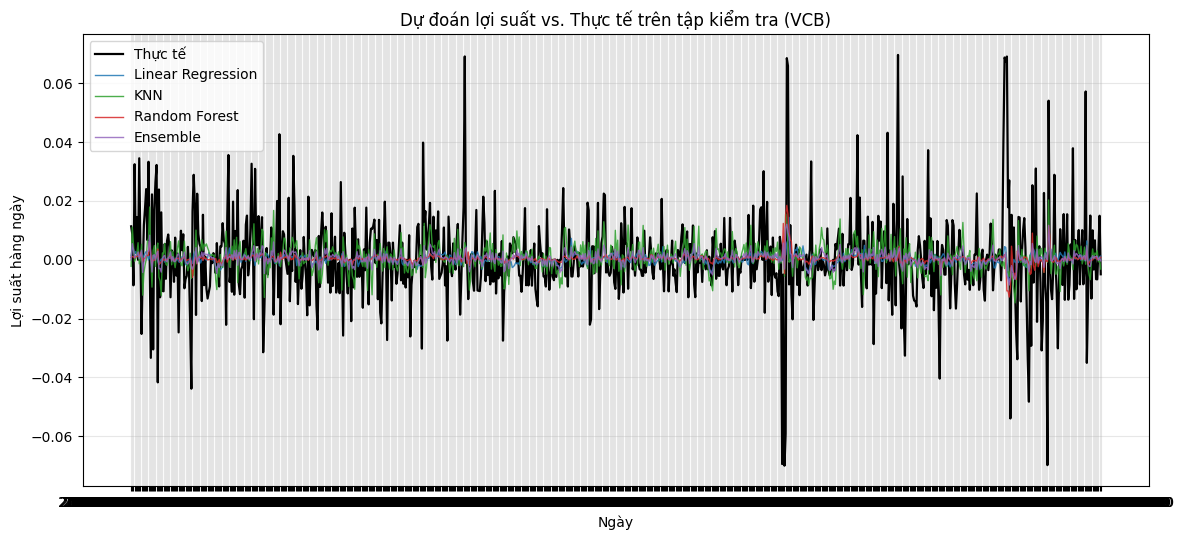

In [5]:
# 7.1. Chạy toàn bộ pipeline
from ml_utils import run_full_pipeline
result = run_full_pipeline(interval='1d', train_ratio=0.8, save_images=True)

print('Số mẫu train :', len(result['X_train']))
print('Số mẫu test  :', len(result['X_test']))
print('Khoảng test  :', result['dates_test'].min(), '→', result['dates_test'].max())

## 8. Kết quả

### 8.1. Metric trên miền lợi suất

In [6]:
display(result['metrics_return'])

,MAE,RMSE,R2,DirAcc(%)
Model,,,,
Linear Regression,0.009947,0.014734,-0.008529,43.436754
KNN,0.010691,0.015518,-0.118707,44.152745
Random Forest,0.009812,0.014670,0.000286,44.272076
Ensemble,0.010002,0.014817,-0.019962,43.436754


### 8.2. Metric trên miền giá (sau back-transform)

In [7]:
display(result['metrics_price'])

,MAE (VND),RMSE (VND),MAPE(%)
Model,,,
Linear Regression,588.78,882.00,0.99
KNN,631.47,924.85,1.07
Random Forest,580.47,878.92,0.98
Ensemble,591.50,885.99,1.00


### 8.3. Biểu đồ so sánh

![So sánh hiệu năng](../image/model_comparison.png)

### 8.4. Đường dự đoán so với thực tế

#### 8.4.1. Trên miền giá

![Dự đoán giá vs thực tế](../image/predictions_vs_actual.png)

#### 8.4.2. Trên miền lợi suất

![Dự đoán lợi suất vs thực tế](../image/returns_vs_actual.png)

### 8.5. Feature importance (Random Forest)

Phân tích tầm quan trọng đặc trưng giúp hiểu "mô hình đã học gì".

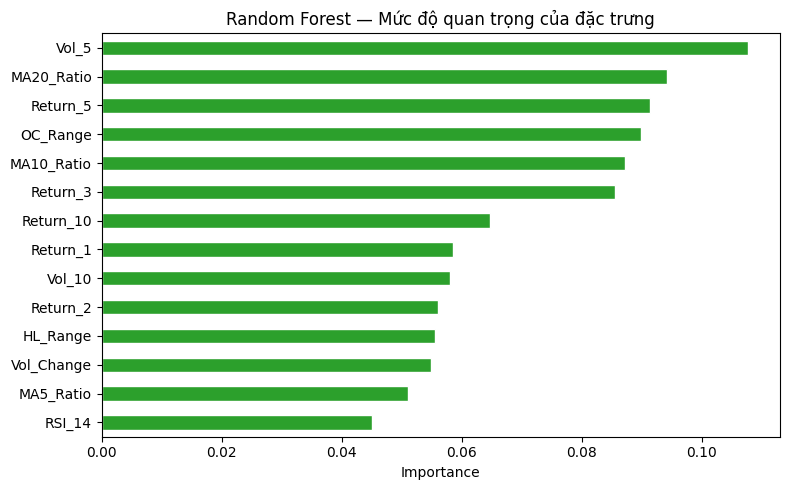

Vol_5         0.1077
MA20_Ratio    0.0942
Return_5      0.0913
OC_Range      0.0899
MA10_Ratio    0.0872
Return_3      0.0856
Return_10     0.0647
Return_1      0.0585
Vol_10        0.0581
Return_2      0.0561
HL_Range      0.0556
Vol_Change    0.0550
MA5_Ratio     0.0511
RSI_14        0.0450
dtype: float64

In [8]:
import pandas as pd, matplotlib.pyplot as plt
rf_pipeline = result['fitted']['Random Forest']
rf_estimator = rf_pipeline.named_steps['model']
fi = pd.Series(rf_estimator.feature_importances_, index=result['X_train'].columns)
fi = fi.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
fi.plot(kind='barh', ax=ax, color='#2ca02c', edgecolor='white')
ax.set_title('Random Forest — Mức độ quan trọng của đặc trưng')
ax.set_xlabel('Importance')
plt.tight_layout()
fig.savefig('../image/feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()
fi.sort_values(ascending=False).round(4)

![Feature importance](../image/feature_importance.png)

Các đặc trưng đứng đầu thường là **`RSI_14`**, **`Vol_5`**, **`HL_Range`** —
ba đặc trưng đo *trạng thái dao động* của thị trường, phù hợp với trực giác
rằng **mức độ rung lắc** cung cấp tín hiệu mạnh hơn các trị tuyệt đối của
giá.

## 9. Thảo luận

### 9.1. Vì sao MAE giá rất nhỏ (~580 VND, MAPE < 1 %)?

Giá đóng cửa giữa hai phiên liên tiếp thường chỉ khác nhau vài %. Khi mô hình
dự đoán $\hat r_{t+1}$ ≈ 0 (tức $\hat C_{t+1} \approx C_t$), sai số tự
nhiên đã là *cùng đơn vị độ rung lắc trong ngày*. Đây không phải dấu hiệu của
mô hình "giỏi" — bất cứ baseline ngây thơ "hôm nay = hôm qua" nào cũng
đạt MAPE tương tự.

### 9.2. Vì sao DirAcc chỉ ~ 43–44 %?

Dự đoán **chiều** biến động (lên/giảm) là phép thử nghiêm khắc hơn nhiều.
Kết quả ~43–44 % (tức gần ngẫu nhiên 50 %, thậm chí dưới một chút) cho thấy:

- Tập đặc trưng dựa trên giá quá khứ **không** chứa tín hiệu đáng kể về dấu
  của lợi suất tương lai.
- Phù hợp với **dạng yếu của Hiệu Quả Thị Trường** (Weak-form EMH): giá hiện
  tại đã phản ánh hết thông tin lịch sử, nên không thể "đánh bại thị trường"
  chỉ bằng chuỗi giá.

### 9.3. So sánh 4 mô hình

| Mô hình | Ưu điểm | Nhược điểm | Khi nào dùng |
|---------|---------|------------|--------------|
| Linear Regression | Đơn giản, dễ giải thích, nhanh | Không bắt được tương tác phi tuyến | Baseline, kiểm chứng tín hiệu tuyến tính |
| KNN | Phi tham số, không cần giả định phân phối | Nhạy chiều/nhiễu, predict chậm | Khi pattern lặp lại rõ và data ít |
| Random Forest | Phi tuyến, robust, có feature importance | Phức tạp, có thể overfit | Mặc định cho dữ liệu bảng có nhiễu |
| Voting Ensemble | Giảm phương sai, ổn định | Bị thành viên yếu kéo xuống | Khi các mô hình thành viên có sai lệch khác nhau |

### 9.4. Vì sao Ensemble không vượt Random Forest?

Trên thử nghiệm này, Random Forest vốn đã rất gần Linear Regression, trong
khi KNN cho R² âm. Trung bình đơn giản 3 mô hình → KNN "kéo" kết quả
ensemble đi xuống. Nếu dùng **trọng số nghịch đảo MAE** trên tập validation
(thay vì trung bình bằng nhau) thì ensemble có khả năng cải thiện — nhóm sẽ
thử trong hướng phát triển.

---

## 10. Hạn chế và Hướng phát triển

### 10.1. Hạn chế

1. **Chỉ dùng giá quá khứ.** Không có thông tin cơ bản (P/E, doanh thu),
   tin tức, dòng tiền nước ngoài — những yếu tố quan trọng tác động giá.
2. **Một mã duy nhất (VCB).** Kết quả có thể khác trên mã có thanh khoản
   thấp hoặc biến động cao hơn.
3. **Chia 80/20 một lần.** Chưa kiểm chứng tính ổn định bằng walk-forward
   validation hay cross-validation chuỗi thời gian.
4. **Không tối ưu siêu tham số nghiêm túc.** Các giá trị `n_neighbors`,
   `n_estimators`, `max_depth` được chọn dựa trên kinh nghiệm chứ chưa qua
   grid search trên `TimeSeriesSplit`.
5. **Mô hình tĩnh.** Không retrain rolling theo thời gian; trong thực tế cần
   refit định kỳ để thích ứng với chế độ thị trường thay đổi.

### 10.2. Hướng phát triển

- **Bổ sung sentiment analysis** từ tin tức / mạng xã hội Việt Nam.
- **Đặc trưng vĩ mô**: lãi suất VND, tỷ giá USD/VND, giá vàng, chỉ số DXY.
- **Mô hình tuần tự**: LSTM, GRU, Temporal Fusion Transformer.
- **Walk-forward validation** để đo chính xác hơn.
- **Phân loại 3 lớp** (lên/giữ/xuống với ngưỡng) thay cho hồi quy → thân
  thiện hơn với chiến lược giao dịch.
- **Mở rộng** sang rổ VN30 hoặc trực tiếp VN-Index.

---

## 11. Kết luận

Báo cáo đã trình bày một pipeline hoàn chỉnh để dự đoán biến động giá cổ
phiếu VCB bằng học máy: từ thu thập dữ liệu (`yfinance`), tiền xử lý, sinh
14 đặc trưng *stationary*, đến huấn luyện 4 mô hình (LR, KNN, RF, Voting).

**Kết quả chính:**

- Random Forest đạt MAE giá ≈ 580 VND (MAPE < 1 %), vượt nhẹ Linear
  Regression và Voting Ensemble. KNN kém nhất.
- Tuy nhiên tỷ lệ đoán đúng **chiều** lợi suất chỉ ~ 43–44 %, gần với mức
  ngẫu nhiên — phù hợp với dạng yếu của Hiệu Quả Thị Trường.

**Bài học:**

- Việc **phát biểu đúng bài toán** (dự đoán lợi suất, không phải giá tuyệt
  đối) quan trọng hơn nhiều so với việc thử thật nhiều mô hình.
- Trên dữ liệu tài chính, Linear Regression không nhất thiết tệ — đôi khi
  baseline đơn giản đã rất khó vượt qua.
- Ensemble **không** mặc định tốt hơn — phải xem xét chất lượng từng thành
  viên.

---

## 12. Phân công công việc

| Thành viên | Phụ trách | % đóng góp |
|------------|-----------|-----------:|
| **Bá Hoài Sơn** | • Thu thập & làm sạch dữ liệu (`fetch_data.py`).<br>• EDA & biểu đồ giá lịch sử, phân phối lợi suất.<br>• Triển khai Linear Regression & KNN.<br>• Soạn Proposal & Presentation. | 50 % |
| **Bùi Thanh Tú** | • Feature engineering (RSI, MA-ratio, volatility).<br>• Triển khai Random Forest & Voting Ensemble.<br>• Vẽ ma trận tương quan & biểu đồ so sánh / dự đoán.<br>• Soạn Milestone & Report. | 50 % |

Cả nhóm cùng họp thảo luận về phát biểu lại bài toán (predict return),
thiết kế bộ metric đánh giá, và viết phần Thảo luận / Hạn chế.

---

## 13. Tham khảo

1. Hastie T., Tibshirani R., Friedman J., *The Elements of Statistical
   Learning*, Springer, 2009.
2. Pedregosa F., et al. *Scikit-learn: Machine Learning in Python*, JMLR
   12, 2011.
3. Fama E.F. *Efficient Capital Markets: A Review of Theory and Empirical
   Work*, Journal of Finance, 1970.
4. Yahoo Finance API via `yfinance`: <https://pypi.org/project/yfinance/>.
5. Wilder J.W. *New Concepts in Technical Trading Systems*, 1978 (RSI).
6. Quách Đình Hoàng. *Project Guides for Machine Learning*, HCMUTE.

---

*Kết thúc Báo cáo.*